# PI MONIT - Satellite packet data conversion

## Define data structures and formats
Here we use the `struct` module to define the binary formats for the header and samples. The header contains metadata about the dive, while the samples contain the actual temperature and pressure readings.

See https://docs.python.org/3/library/struct.html for more informations.

In [25]:
import struct
import pandas as pd
from dataclasses import dataclass

# little-endian, without padding
# Header:
# uint8_t   header_len
# uint16_t  dive_id
# uint16_t  gps_week
# uint32_t  gps_tow_s
# int32_t   lat
# int32_t   lon
# uint16_t  sample_period_ms
# uint16_t  sample_count

HEADER_FMT = "<B H H I i i H H"
SAMPLE_FMT = "<h H"  # int16 temperature, uint16 pressure

HEADER_SIZE = struct.calcsize(HEADER_FMT)
SAMPLE_SIZE = struct.calcsize(SAMPLE_FMT)

print("Header size:", HEADER_SIZE)
print("Sample size:", SAMPLE_SIZE)

Header size: 21
Sample size: 4


In [ ]:
@dataclass
class DiveHeader:
    header_len: int
    dive_id: int
    gps_week: int
    gps_tow_s: int
    lat_raw: int
    lon_raw: int
    lat: float
    lon: float
    sample_period_ms: int
    sample_count: int


def decode_header(data: bytes) -> DiveHeader:
    if len(data) < HEADER_SIZE:
        raise ValueError(f"Payload trop court pour le header: {len(data)} bytes")

    values = struct.unpack_from(HEADER_FMT, data, 0)

    (
        header_len,
        dive_id,
        gps_week,
        gps_tow_s,
        lat_raw,
        lon_raw,
        sample_period_ms,
        sample_count,
    ) = values

    # Classical GPS hypthesis: 1e7 coordinates
    lat = lat_raw / 1e7
    lon = lon_raw / 1e7

    return DiveHeader(
        header_len=header_len,
        dive_id=dive_id,
        gps_week=gps_week,
        gps_tow_s=gps_tow_s,
        lat_raw=lat_raw,
        lon_raw=lon_raw,
        lat=lat,
        lon=lon,
        sample_period_ms=sample_period_ms,
        sample_count=sample_count,
    )

## Decoding function
The `decode_dive_payload` function takes the raw bytes of the packet, unpacks the
header and samples according to the defined formats, and returns a structured representation of the data.

In [ ]:
def decode_samples(data: bytes, header: DiveHeader) -> pd.DataFrame:
    offset = header.header_len  # Should be equal to HEADER_SIZE, but we trust the header value
    samples = []

    expected_size = offset + header.sample_count * SAMPLE_SIZE

    if len(data) < expected_size:
        raise ValueError(
            f"Incomplete payload: {len(data)} bytes received, "
            f"{expected_size} bytes expected"
        )

    for i in range(header.sample_count):
        temp_raw, pressure_hpa = struct.unpack_from(SAMPLE_FMT, data, offset)
        offset += SAMPLE_SIZE

        samples.append({
            "sample": i,
            "time_s": i * header.sample_period_ms / 1000,
            "temperature_raw": temp_raw,
            "temperature_c": temp_raw / 100,
            "pressure_hpa": pressure_hpa,
        })

    return pd.DataFrame(samples)

In [20]:
def decode_dive_payload(data: bytes):
    header = decode_header(data)
    samples_df = decode_samples(data, header)
    return header, samples_df

## Implementation example
Here is an example of how to implement the decoding function and use it to read a sample payload. This example assumes that you have a binary payload that follows the defined structure and that you want to convert it into a more usable format, such as a pandas DataFrame.

In [30]:
with open("data/dive_data_simu.hex", "r") as f:
    packet_hex = f.read().strip()

packet_bytes = bytes.fromhex(packet_hex)

header, samples_df = decode_dive_payload(packet_bytes)
print(header)
print(samples_df)

DiveHeader(header_len=21, dive_id=1, gps_week=2300, gps_tow_s=250000, lat_raw=462044000, lon_raw=61432000, lat=46.2044, lon=6.1432, sample_period_ms=1000, sample_count=600)
     sample  time_s  temperature_raw  temperature_c  pressure_hpa
0         0     0.0             2200           22.0          1013
1         1     1.0             2200           22.0          1013
2         2     2.0             2200           22.0          1013
3         3     3.0             2200           22.0          1013
4         4     4.0             2200           22.0          1013
..      ...     ...              ...            ...           ...
595     595   595.0             2200           22.0          1013
596     596   596.0             2200           22.0          1013
597     597   597.0             2200           22.0          1013
598     598   598.0             2200           22.0          1013
599     599   599.0             2200           22.0          1013

[600 rows x 5 columns]


## Plot the dive values

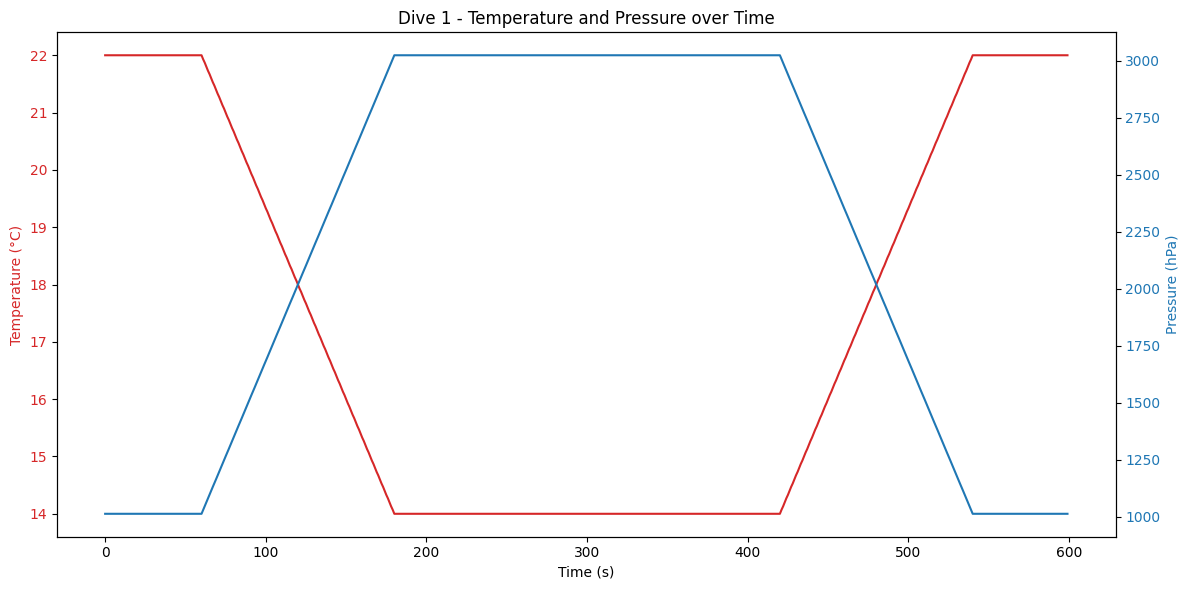

In [31]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# Temperature on left axis
color_temp = "tab:red"
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Temperature (°C)", color=color_temp)
ax1.plot(samples_df["time_s"], samples_df["temperature_c"], color=color_temp, label="Temperature")
ax1.tick_params(axis="y", labelcolor=color_temp)

# Pressure on right axis
ax2 = ax1.twinx()
color_press = "tab:blue"
ax2.set_ylabel("Pressure (hPa)", color=color_press)
ax2.plot(samples_df["time_s"], samples_df["pressure_hpa"], color=color_press, label="Pressure")
ax2.tick_params(axis="y", labelcolor=color_press)

plt.title(f"Dive {header.dive_id} - Temperature and Pressure over Time")
fig.tight_layout()
plt.show()

**Remarks**: The dive data are really symetric since they have been generated with a simple mathematical function. In real life, the data will be more noisy and less symetric. The plot is just for demonstration purposes.